 ## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set styles
sns.set(style="whitegrid")
%matplotlib inline


## 2. Load Dataset

In [ ]:
# Load the messy dataset
df = pd.read_csv('data/animal_data_dirty1.csv') 
df.head()


,Animal type;Country;Weight kg;Body Length cm;Gender;Animal code;Latitude;Longitude;Animal name;Observation date;Data compiled by
0,;;;;;;;;;03.01.2024;James Johnson
1,;;;;;;;;;03.02.2024;James Johnson
2,European bison;Poland;930;335;male;;52.828845;...
3,European bison;Poland;909;311;not determined;;...
4,European bison™;Poland;581;277;female;;52.8341...


## Step 3: Load Dataset (Properly)

In [ ]:
# Load using correct delimiter
df = pd.read_csv('data/animal_data_dirty1.csv', sep=';')

# Drop empty or corrupt first few rows (e.g., rows with all nulls or just delimiters)
df = df.dropna(how='all')  # drop fully blank rows
df = df[~df['Animal type'].isna()]  # remove rows with no animal info

df.head()


,Animal type,Country,Weight kg,Body Length cm,Gender,Animal code,Latitude,Longitude,Animal name,Observation date,Data compiled by
2,European bison,Poland,930.0,335.0,male,NaN,52.828845,23.820144,Szefu,01.03.2024,Anne Anthony
3,European bison,Poland,909.0,311.0,not determined,NaN,52.830509,23.826849,NaN,01.03.2024,Anne Anthony
4,European bison™,Poland,581.0,277.0,female,NaN,52.834109,23.807093,NaN,01.03.2024,Anne Anthony
5,European bisson,Poland,900.0,295.0,male,NaN,52.834759,23.817201,NaN,01.03.2024,Anne Anthony
6,European buster,Poland,620.0,250.0,female,NaN,52.834960,23.820750,NaN,01.03.2024,Anne Anthony


In [ ]:
# Strip spaces, lowercase, and convert to underscore format
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns


Index(['animal_type', 'country', 'weight_kg', 'body_length_cm', 'gender',
       'animal_code', 'latitude', 'longitude', 'animal_name',
       'observation_date', 'data_compiled_by'],
      dtype='object')

## Step 4: Initial Exploration
Here, we inspect the shape, data types, missing values, and duplicates — which helps us plan cleaning strategies.

In [ ]:
# Shape of the dataset
print("Shape of dataset:", df.shape)

# Overview of data types
df.info()

# Summary statistics (numeric and object types)
df.describe(include='all')

# Check for missing values in each column
print("\nMissing values per column:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Preview some unique values for object-type columns (for spotting issues)
for col in df.select_dtypes(include='object').columns:
    print(f"\nUnique values in '{col}':")
    print(df[col].unique()[:10])  # Preview top 10


Shape of dataset: (991, 11)
<class 'pandas.core.frame.DataFrame'>
Index: 991 entries, 2 to 1010
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   animal_type       991 non-null    object 
 1   country           991 non-null    object 
 2   weight_kg         976 non-null    float64
 3   body_length_cm    976 non-null    float64
 4   gender            984 non-null    object 
 5   animal_code       0 non-null      float64
 6   latitude          913 non-null    float64
 7   longitude         913 non-null    float64
 8   animal_name       52 non-null     object 
 9   observation_date  991 non-null    object 
 10  data_compiled_by  991 non-null    object 
dtypes: float64(5), object(6)
memory usage: 92.9+ KB

Missing values per column:
animal_type           0
country               0
weight_kg            15
body_length_cm       15
gender                7
animal_code         991
latitude             78
longitude  

## Key Findings from Initial Exploration

Before cleaning the data, we examined the structure, data types, and missing values. Here are the key issues identified:

| **Column**             | **Issue**                                                                 |
|------------------------|---------------------------------------------------------------------------|
| `animal_code`          | All values are null — we will drop this column.                           |
| `weight_kg` & `body_length_cm` | 15 missing values each — we will impute using the **median**.               |
| `latitude` & `longitude` | 78 missing rows — since these are important for geospatial analysis, we will **drop rows** with missing values. |
| `animal_name`          | Only 52 values filled — likely non-essential, so we will retain it as-is. |
| `gender`               | Contains inconsistent values like `"not determined"`, `"F"`, `"female "` — we will standardize them. |
| `animal_type`          | Contains typos or special characters (e.g., `"European bison™"`) — we will clean this field. |
| `observation_date`     | All values are present but stored as **strings** — we will convert to `datetime`. |
| `data_compiled_by`     | Looks consistent — contains names of 4 contributors.                      |

These issues will be addressed in the next step to prepare the dataset for EDA and visualization.


## 🧼 Step 5: Data Cleaning

Now that we've inspected the dataset, we will clean it by addressing:

- ❌ Columns with entirely missing data (like `animal_code`)
- ❗ Inconsistent text formatting in `animal_type` and `gender`
- 📅 Date formatting in `observation_date` (currently as string)
- 🧩 Missing values in key numeric fields (`weight_kg`, `body_length_cm`)
- 🌍 Missing geolocation values (latitude and longitude)

We aim to prepare the data for meaningful analysis and visualizations.


In [ ]:
# 1. Drop columns that are fully empty
df = df.drop(columns=['animal_code'])

# 2. Clean and standardize string columns
df['gender'] = df['gender'].str.strip().str.lower()
df['gender'] = df['gender'].replace({
    'f': 'female',
    'm': 'male',
    'female ': 'female',
    'male ': 'male',
    'not determined': 'unknown'
})

df['animal_type'] = df['animal_type'].str.strip().str.replace("™", "").str.lower()

# 3. Fix date format (European format: DD.MM.YYYY)
df['observation_date'] = pd.to_datetime(df['observation_date'], dayfirst=True, errors='coerce')

# 4. Handle missing values
# Drop rows missing latitude/longitude (since it's important for location-based visuals)
df = df.dropna(subset=['latitude', 'longitude'])

# Fill numeric columns with median
df['weight_kg'] = df['weight_kg'].fillna(df['weight_kg'].median())
df['body_length_cm'] = df['body_length_cm'].fillna(df['body_length_cm'].median())

# 5. Re-check cleaned data
print("\nAfter cleaning:")
print(df.info())



After cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 913 entries, 2 to 1010
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   animal_type       913 non-null    object        
 1   country           913 non-null    object        
 2   weight_kg         913 non-null    float64       
 3   body_length_cm    913 non-null    float64       
 4   gender            906 non-null    object        
 5   latitude          913 non-null    float64       
 6   longitude         913 non-null    float64       
 7   animal_name       52 non-null     object        
 8   observation_date  874 non-null    datetime64[ns]
 9   data_compiled_by  913 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(5)
memory usage: 78.5+ KB
None


### 🔧 Final Cleanup

- Filled missing `gender` values with `"unknown"` to standardize the category.
- Dropped rows with missing or invalid `observation_date`, as they are needed for any time-based visualizations.

With these final adjustments, our dataset is now fully cleaned and ready for EDA and visualization.


In [ ]:
df['gender'] = df['gender'].fillna('unknown')


In [ ]:
df = df.dropna(subset=['observation_date'])


### 🔢 Numerical Overview

We begin by exploring the distribution of key numerical features:
- `weight_kg`
- `body_length_cm`

This gives us a sense of scale, outliers, and potential anomalies.


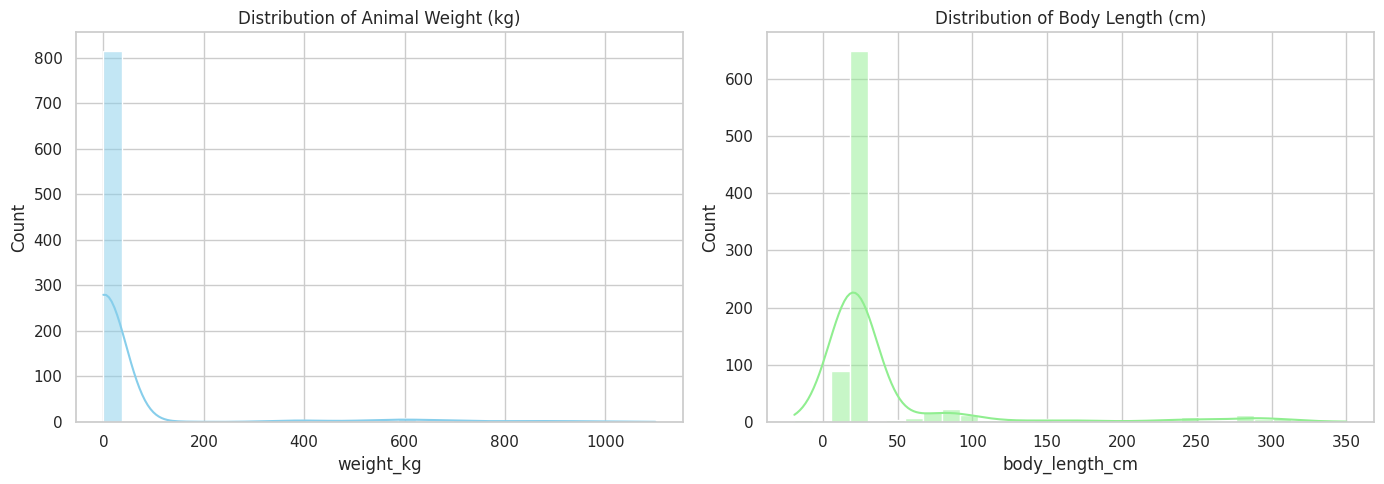

In [ ]:
# Set a clean style
sns.set(style="whitegrid")

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['weight_kg'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Animal Weight (kg)')

sns.histplot(df['body_length_cm'], bins=30, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Body Length (cm)')

plt.tight_layout()
plt.show()


✅ This shows histograms with KDE (smoothed curves) to spot skewed distributions or outliers.

### 🐾 Distribution of Animal Types

Next, we’ll explore how the observations are distributed across different animal types. This helps identify any imbalances or interesting trends in the dataset.


/tmp/ipykernel_4601/582836697.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='animal_type', order=df['animal_type'].value_counts().index, palette='viridis')


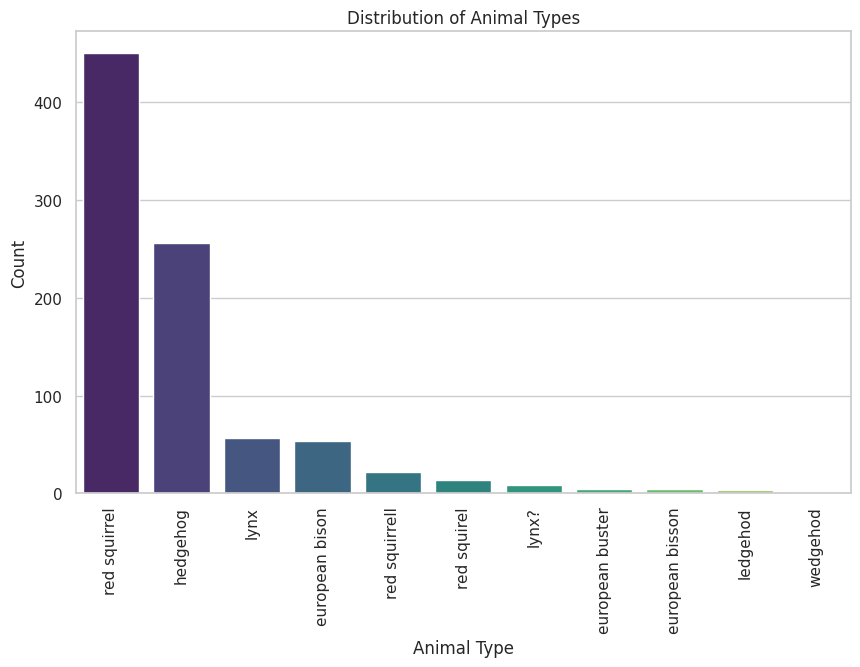

In [ ]:
# Plot distribution of animal types
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='animal_type', order=df['animal_type'].value_counts().index, palette='viridis')
plt.xticks(rotation=90)  # Rotate labels for readability
plt.title('Distribution of Animal Types')
plt.xlabel('Animal Type')
plt.ylabel('Count')
plt.show()


### 🛠 Fixing Inconsistent Animal Types

We noticed that the animal type "lynx?" was listed alongside "lynx". To ensure consistency, we replaced all occurrences of "lynx?" with "lynx".

In [ ]:
# Replace 'lynx?' with 'lynx' in the animal_type column
df['animal_type'] = df['animal_type'].replace('lynx?', 'lynx')


: 

In [ ]:
# Plot distribution of animal types
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='animal_type', order=df['animal_type'].value_counts().index, palette='viridis')
plt.xticks(rotation=90)  # Rotate labels for readability
plt.title('Distribution of Animal Types')
plt.xlabel('Animal Type')
plt.ylabel('Count')
plt.show()


✅ This is a bar plot showing the frequency of each animal type.

### 🚻 Gender Distribution

We’ll now analyze the distribution of gender across the dataset. This will help us understand the gender breakdown and any potential biases in the data.


/tmp/ipykernel_4601/2060499212.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', palette='muted')


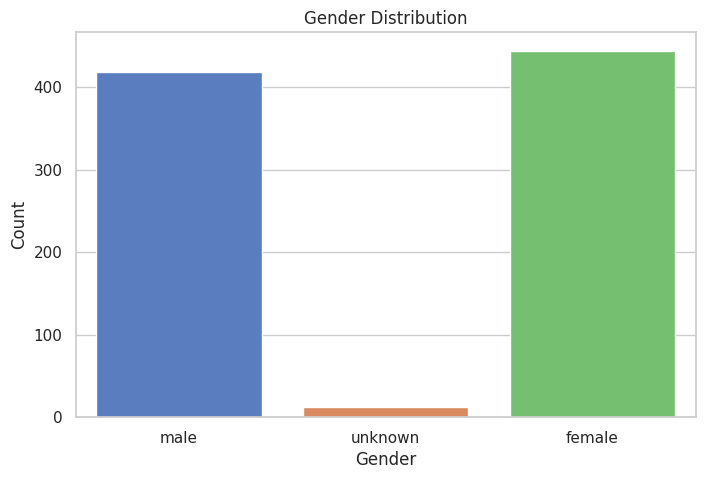

In [ ]:
# Plot distribution of gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender', palette='muted')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


✅ This is a bar plot of gender distribution.

### 🌍 Country-wise Observations

In this step, we will explore the number of observations made in each country. This will provide insights into which regions have more recorded animal sightings.


/tmp/ipykernel_4601/3452419202.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='country', order=df['country'].value_counts().index, palette='Blues')


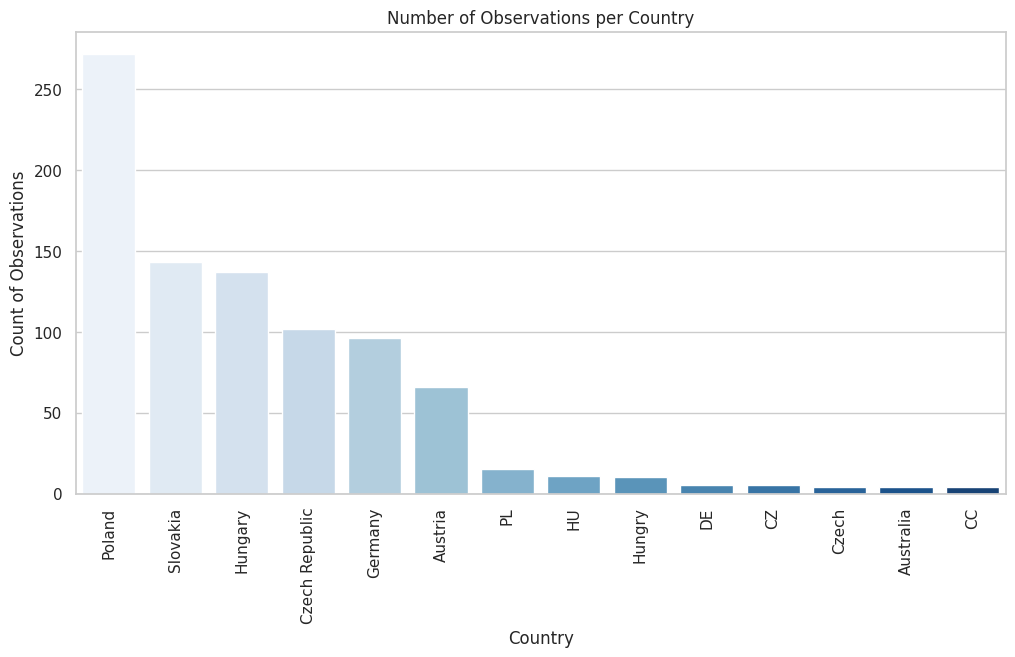

In [ ]:
# Plot number of observations per country
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='country', order=df['country'].value_counts().index, palette='Blues')
plt.xticks(rotation=90)  # Rotate country names for readability
plt.title('Number of Observations per Country')
plt.xlabel('Country')
plt.ylabel('Count of Observations')
plt.show()


✅ This is a bar plot of the number of observations by country.

### 📅 Trends Over Time

Let’s explore how the observations are distributed over time. This can reveal patterns such as seasonal trends or spikes in observations during specific months.


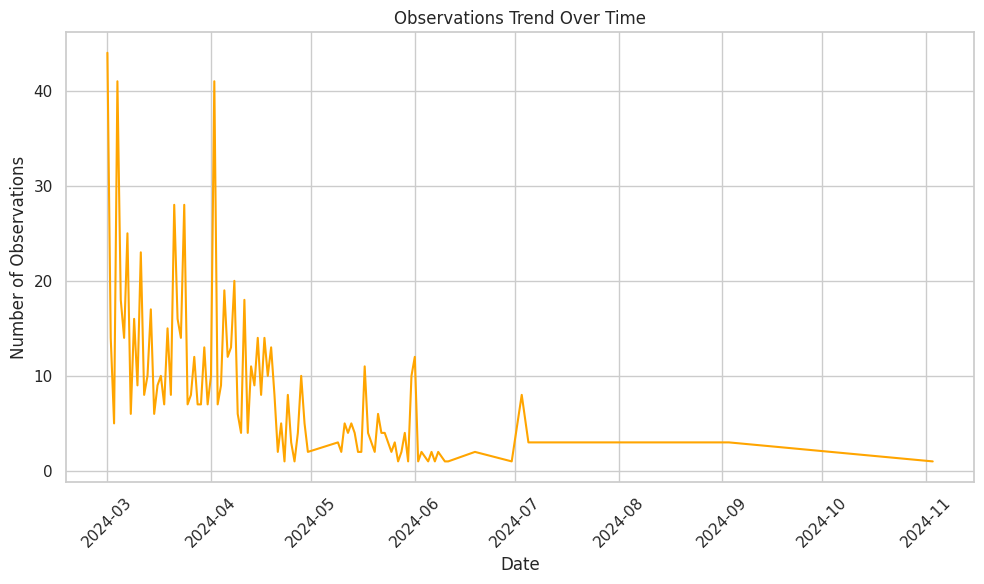

In [ ]:
# Ensure the observation_date is in datetime format
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')

# Group by observation date and count the number of occurrences per day
daily_obs = df.groupby('observation_date').size().reset_index(name='counts')

# Plot trends over time (observation date)
plt.figure(figsize=(10, 6))
sns.lineplot(data=daily_obs, x='observation_date', y='counts', color='orange')
plt.title('Observations Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)  # Rotate dates for readability
plt.tight_layout()
plt.show()


### 🌍 Geospatial Overview

In this step, we’ll create a scatter plot to visualize the geographic spread of the animal observations based on latitude and longitude. This helps us understand where most of the data points are located.


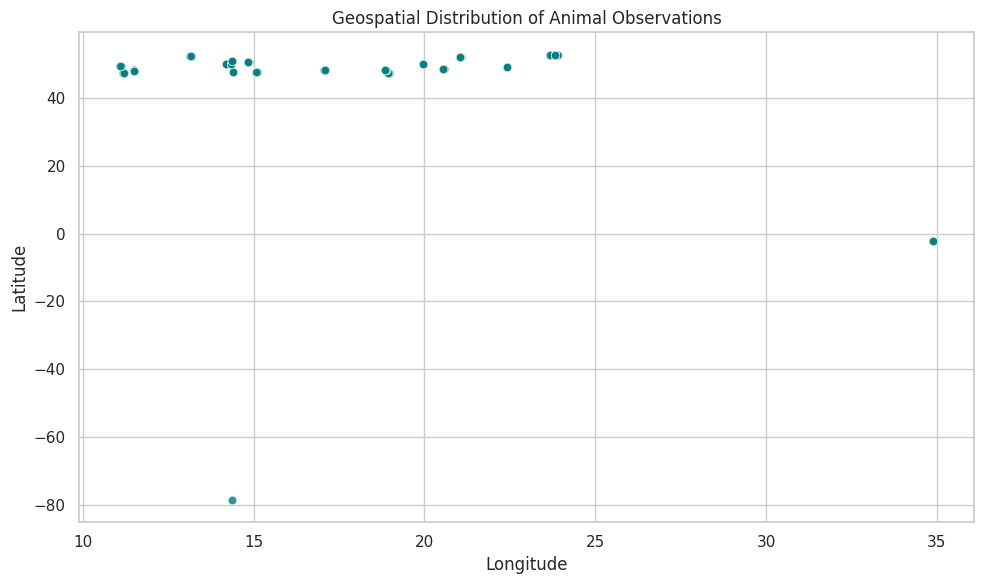

In [ ]:
# Plot latitude vs longitude
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='longitude', y='latitude', color='teal', alpha=0.6)
plt.title('Geospatial Distribution of Animal Observations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()
